# Executive Summary Notebook: NVDA–TSLA Spread Prediction and Long–Short Backtest

This notebook is written as a **presentation-ready executive summary** for a 10-minute talk.

The notebook does **not** rerun model training. It reads the saved CSV outputs under `outputs/tables/` and rebuilds the main tables and figures from those files only.

**Core takeaway in one sentence.**  
The project asks whether 15 accounting and momentum-based pair features can predict the next-day NVDA–TSLA return spread well enough to support a profitable long–short strategy after validation tuning and transaction costs. The answer is mixed: the models can learn statistical patterns, and the validation-tuned multiclass logit is the most stable on out-of-sample classification accuracy, but **none of the four ML strategies beats the simple momentum benchmark on out-of-sample net portfolio performance**.


## 1. Load saved outputs only

For this presentation notebook, I load the already-saved results from `outputs/tables/`.  
That keeps the workflow light and reproducible, and avoids rerunning the rolling-window tuning pipeline.


In [1]:
from pathlib import Path
import ast
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
TABLE_DIR = ROOT / "outputs" / "tables"
FIG_DIR = ROOT / "outputs" / "figures"

required_files = [
    "rolling_windows.csv",
    "tuning_summary_all_models.csv",
    "best_params_summary_all_models.csv",
    "classification_summary_all_models.csv",
    "confusion_summary_all_models.csv",
    "portfolio_summary_all_models.csv",
    "relative_summary_all_models.csv",
    "predictions_all_models.csv",
]

missing = [f for f in required_files if not (TABLE_DIR / f).exists()]
if missing:
    print("Missing files:", missing)
    print("Make sure this notebook is placed inside your project root, next to the outputs/ folder.")
else:
    print("All required CSV files found.")

windows = pd.read_csv(TABLE_DIR / "rolling_windows.csv", parse_dates=["train_start","train_end","val_start","val_end","test_start","test_end"])
tuning_summary = pd.read_csv(TABLE_DIR / "tuning_summary_all_models.csv")
best_params_summary = pd.read_csv(TABLE_DIR / "best_params_summary_all_models.csv")
classification_summary = pd.read_csv(TABLE_DIR / "classification_summary_all_models.csv")
confusion_summary = pd.read_csv(TABLE_DIR / "confusion_summary_all_models.csv")
portfolio_summary = pd.read_csv(TABLE_DIR / "portfolio_summary_all_models.csv")
relative_summary = pd.read_csv(TABLE_DIR / "relative_summary_all_models.csv")
predictions = pd.read_csv(TABLE_DIR / "predictions_all_models.csv", parse_dates=["date"])

print("Number of rolling windows:", windows["window_id"].nunique())
print("Date span covered by rolling windows:", windows["train_start"].min().date(), "to", windows["test_end"].max().date())


All required CSV files found.
Number of rolling windows: 40
Date span covered by rolling windows: 2010-09-28 to 2025-12-27


## 2. Project goal, data source, and cleaning pipeline

Here is the story I would tell at the start of the presentation.

I start from the `mag7.pickle` daily panel and restrict attention to **two stocks: NVDA and TSLA**.  
For each stock-date observation, the raw panel contains adjusted close, volume, and accounting variables aligned to the daily data.

Then I do four cleaning and construction steps:

1. compute daily adjusted returns for each stock;
2. align the two stocks on common dates;
3. build 15 feature differences of the form `NVDA minus TSLA`;
4. define the prediction target using the **next-day spread**
$$
s_{t+1} = r_{NVDA,t+1} - r_{TSLA,t+1}.
$$

After lagging returns and rolling indicators, the usable sample is evaluated with **40 rolling windows**.


In [2]:
config_snapshot = pd.DataFrame(
    {
        "value": [
            "NVDA",
            "TSLA",
            15,
            5,
            3,
            3,
            3,
            0.5,
            5.0,
            "sharpe",
            "[0.5, 0.6, 0.67, 0.75]",
            "[0.01, 0.1, 1.0, 10.0, 100.0]",
            "[(16,), (32,), (32, 16), (64, 32)]",
            "[1e-05, 0.0001, 0.001, 0.01]",
            "[0.0005, 0.001]",
        ]
    },
    index=[
        "symbol_a",
        "symbol_b",
        "n_features",
        "train_years",
        "val_months",
        "test_months",
        "step_months",
        "binary_threshold",
        "transaction_cost_bps",
        "selection_objective",
        "multiclass_quantile_grid",
        "logit_C_grid",
        "nn_hidden_layer_grid",
        "nn_alpha_grid",
        "nn_learning_rate_init_grid",
    ],
)
display(config_snapshot)
display(windows.head())
display(windows.tail())


,value
symbol_a,NVDA
symbol_b,TSLA
n_features,15
train_years,5
val_months,3
test_months,3
step_months,3
binary_threshold,0.5
transaction_cost_bps,5.0
selection_objective,sharpe


,window_id,train_start,train_end,val_start,val_end,test_start,test_end,n_train,n_val,n_test
0,win_01,2010-09-28,2015-09-27,2015-09-28,2015-12-27,2015-12-28,2016-03-27,1258,63,61
1,win_02,2010-12-28,2015-12-27,2015-12-28,2016-03-27,2016-03-28,2016-06-27,1258,61,65
2,win_03,2011-03-28,2016-03-27,2016-03-28,2016-06-27,2016-06-28,2016-09-27,1257,65,64
3,win_04,2011-06-28,2016-06-27,2016-06-28,2016-09-27,2016-09-28,2016-12-27,1258,64,63
4,win_05,2011-09-28,2016-09-27,2016-09-28,2016-12-27,2016-12-28,2017-03-27,1258,63,61


,window_id,train_start,train_end,val_start,val_end,test_start,test_end,n_train,n_val,n_test
35,win_36,2019-06-28,2024-06-27,2024-06-28,2024-09-27,2024-09-28,2024-12-27,1259,64,63
36,win_37,2019-09-28,2024-09-27,2024-09-28,2024-12-27,2024-12-28,2025-03-27,1259,63,60
37,win_38,2019-12-28,2024-12-27,2024-12-28,2025-03-27,2025-03-28,2025-06-27,1259,60,63
38,win_39,2020-03-28,2025-03-27,2025-03-28,2025-06-27,2025-06-28,2025-09-27,1257,63,63
39,win_40,2020-06-28,2025-06-27,2025-06-28,2025-09-27,2025-09-28,2025-12-27,1257,63,63


## 3. Feature set

The 15 features combine **accounting fundamentals** and **technical indicators**, all defined as pairwise differences:
$$
X_t = X_{NVDA,t} - X_{TSLA,t}.
$$

The accounting block includes profitability, leverage, liquidity, investment intensity, turnover, and size:

- operating margin difference,
- net margin difference,
- leverage difference,
- cash ratio difference,
- R&D intensity difference,
- capex intensity difference,
- asset turnover difference,
- log market cap difference.

The technical block includes:

- 5-day, 21-day, and 63-day momentum differences,
- 20-day moving-average gap difference,
- 14-day RSI difference,
- 21-day realized-volatility difference,
- 20-day volume-shock difference.

So the model always sees the **relative state of NVDA versus TSLA**, not the absolute state of one stock in isolation.


## 4. Model specification

I study two prediction tasks.

### 4.1 Binary classification

The binary target is
$$
y^{(B)}_t = 1\{s_{t+1} > 0\}.
$$

For binary logistic regression, the model is
$$
p_t = \Pr(y^{(B)}_t=1 \mid X_t)
    = \frac{1}{1+\exp\left[-(\beta_0 + X_t'\beta)\right]}.
$$

For the binary neural network, the model replaces the linear index with nonlinear hidden layers:
$$
h_t^{(1)} = \phi(W_1 X_t + b_1), \quad
h_t^{(2)} = \phi(W_2 h_t^{(1)} + b_2), \quad
\hat p_t = \sigma(W_L h_t^{(L-1)} + b_L).
$$

The trading signal is
$$
d_t^{(B)} =
\begin{cases}
1, & \hat p_t > 0.5, \\
0, & \hat p_t = 0.5, \\
-1, & \hat p_t < 0.5.
\end{cases}
$$

### 4.2 Multiclass classification

The multiclass target is
$$
y^{(M)}_t =
\begin{cases}
1, & s_{t+1} \ge q, \\
0, & -q < s_{t+1} < q, \\
-1, & s_{t+1} \le -q,
\end{cases}
$$
where $q$ is a spread threshold chosen from the training data.

The multiclass models output class probabilities for $-1$, $0$, and $1$, and the predicted class is the largest probability:
$$
\hat y^{(M)}_t = \arg\max_{c\in\{-1,0,1\}} \Pr(y^{(M)}_t=c \mid X_t).
$$

The predicted class is used directly as the trading signal:
$$
d_t^{(M)} = \hat y^{(M)}_t.
$$


## 5. Rolling-window design and validation tuning

The pipeline uses a rolling window with:

- 5 years of training data,
- 3 months of validation data,
- 3 months of test data,
- and a 3-month step size.

So each window follows this sequence:

1. fit candidate models on the 5-year training sample;
2. evaluate each candidate on the 3-month validation sample;
3. choose the hyperparameters that maximize **validation Sharpe**;
4. refit the selected model on train plus validation;
5. evaluate once on the final 3-month test sample.

Formally, for a candidate hyperparameter vector $\theta$, the tuning rule is
$$
\theta^* = \arg\max_{\theta \in \Theta}
\text{Sharpe}_{val}(\theta).
$$

This means the validation set genuinely matters for:

- the logistic penalty $C$;
- the multiclass quantile $q$;
- the neural-network hidden-layer size;
- the neural-network penalty $\alpha$;
- the neural-network learning rate.

The four model IDs are:

- `logit_binary`
- `logit_multiclass`
- `nn_binary`
- `nn_multiclass`


## 6. Portfolio construction and evaluation

Given a signal $d_t \in \{-1,0,1\}$, the gross next-day strategy return is
$$
R^{gross}_{t+1} = 0.5\, d_t\, (r_{NVDA,t+1} - r_{TSLA,t+1}).
$$

Transaction costs are deducted using turnover:
$$
R^{net}_{t+1} = R^{gross}_{t+1} - c \times \text{turnover}_t,
$$
with
$$
c = 5 \text{ basis points}.
$$

I evaluate the models from two angles:

### Statistical fit
- accuracy,
- confusion matrices,
- train / validation / test stability.

### Economic value
- cumulative return,
- mean return,
- volatility,
- Sharpe ratio,
- hit rate,
- active rate,
- alpha, beta, and information ratio relative to simple benchmarks.


## 7. Validation-tuning results

This section answers a practical question: **what kind of model complexity did the validation set actually prefer?**

The message is already informative before looking at test performance:

- the logit models often prefer **strong regularization**;
- the multiclass models often prefer **high neutral-zone thresholds**;
- the NN models prefer **moderate hidden-layer sizes with some shrinkage**;
- but flexible NN choices do not automatically translate into better test performance.


In [3]:
best_selection_table = best_params_summary[
    [
        "model_id",
        "window_id",
        "selection_metric",
        "val_accuracy",
        "val_cumulative_return",
        "val_sharpe",
        "multiclass_quantile",
        "C",
        "hidden_layer_sizes",
        "alpha",
        "learning_rate_init",
    ]
].copy()

display(best_selection_table.sort_values(["model_id", "window_id"]).head(20))
print("Total selected rows:", len(best_selection_table))


,model_id,window_id,selection_metric,val_accuracy,val_cumulative_return,val_sharpe,multiclass_quantile,C,hidden_layer_sizes,alpha,learning_rate_init
0,logit_binary,win_01,-0.086344,0.428571,-0.096512,-0.086344,NaN,10.00,NaN,NaN,NaN
1,logit_binary,win_02,0.063125,0.524590,0.055667,0.063125,NaN,1.00,NaN,NaN,NaN
2,logit_binary,win_03,-0.094633,0.538462,-0.099373,-0.094633,NaN,0.10,NaN,NaN,NaN
3,logit_binary,win_04,0.117973,0.625000,0.076761,0.117973,NaN,0.01,NaN,NaN,NaN
4,logit_binary,win_05,-0.003047,0.587302,-0.019149,-0.003047,NaN,0.01,NaN,NaN,NaN
5,logit_binary,win_06,-0.146473,0.459016,-0.118925,-0.146473,NaN,0.01,NaN,NaN,NaN
6,logit_binary,win_07,-0.034326,0.515625,-0.048673,-0.034326,NaN,0.10,NaN,NaN,NaN
7,logit_binary,win_08,0.145902,0.578125,0.130776,0.145902,NaN,0.01,NaN,NaN,NaN
8,logit_binary,win_09,-0.012184,0.507937,-0.014970,-0.012184,NaN,1.00,NaN,NaN,NaN
9,logit_binary,win_10,0.045445,0.475410,0.032895,0.045445,NaN,0.01,NaN,NaN,NaN


Total selected rows: 160


In [4]:
def parameter_frequency(best_df, model_id):
    sub = best_df[best_df["model_id"] == model_id].copy()
    out = []

    param_cols = ["multiclass_quantile", "C", "hidden_layer_sizes", "alpha", "learning_rate_init"]
    for col in param_cols:
        if col not in sub.columns:
            continue
        valid = sub[col].dropna().astype(str)
        if valid.empty:
            continue
        freq = valid.value_counts().reset_index()
        freq.columns = ["choice", "count"]
        freq["parameter"] = col
        freq["share_within_parameter"] = freq["count"] / freq["count"].sum()
        out.append(freq[["parameter", "choice", "count", "share_within_parameter"]])

    if not out:
        return pd.DataFrame(columns=["parameter", "choice", "count", "share_within_parameter"])

    return pd.concat(out, ignore_index=True)

for mid in ["logit_binary", "logit_multiclass", "nn_binary", "nn_multiclass"]:
    print(f"Selected-parameter frequency: {mid}")
    display(parameter_frequency(best_params_summary, mid))


Selected-parameter frequency: logit_binary


,parameter,choice,count,share_within_parameter
0,C,0.01,15,0.375
1,C,0.1,11,0.275
2,C,1.0,9,0.225
3,C,10.0,5,0.125


Selected-parameter frequency: logit_multiclass


,parameter,choice,count,share_within_parameter
0,multiclass_quantile,0.75,26,0.650
1,multiclass_quantile,0.5,11,0.275
2,multiclass_quantile,0.6,2,0.050
3,multiclass_quantile,0.67,1,0.025
4,C,0.01,25,0.625
5,C,1.0,12,0.300
6,C,0.1,3,0.075


Selected-parameter frequency: nn_binary


,parameter,choice,count,share_within_parameter
0,hidden_layer_sizes,"(32, 16)",15,0.375
1,hidden_layer_sizes,"(64, 32)",12,0.300
2,hidden_layer_sizes,"(16,)",7,0.175
3,hidden_layer_sizes,"(32,)",6,0.150
4,alpha,0.01,13,0.325
5,alpha,0.001,12,0.300
6,alpha,0.0001,8,0.200
7,alpha,1e-05,7,0.175
8,learning_rate_init,0.001,22,0.550
9,learning_rate_init,0.0005,18,0.450


Selected-parameter frequency: nn_multiclass


,parameter,choice,count,share_within_parameter
0,multiclass_quantile,0.6,14,0.350
1,multiclass_quantile,0.67,12,0.300
2,multiclass_quantile,0.5,9,0.225
3,multiclass_quantile,0.75,5,0.125
4,hidden_layer_sizes,"(32, 16)",14,0.350
5,hidden_layer_sizes,"(64, 32)",13,0.325
6,hidden_layer_sizes,"(32,)",8,0.200
7,hidden_layer_sizes,"(16,)",5,0.125
8,alpha,1e-05,11,0.275
9,alpha,0.001,11,0.275


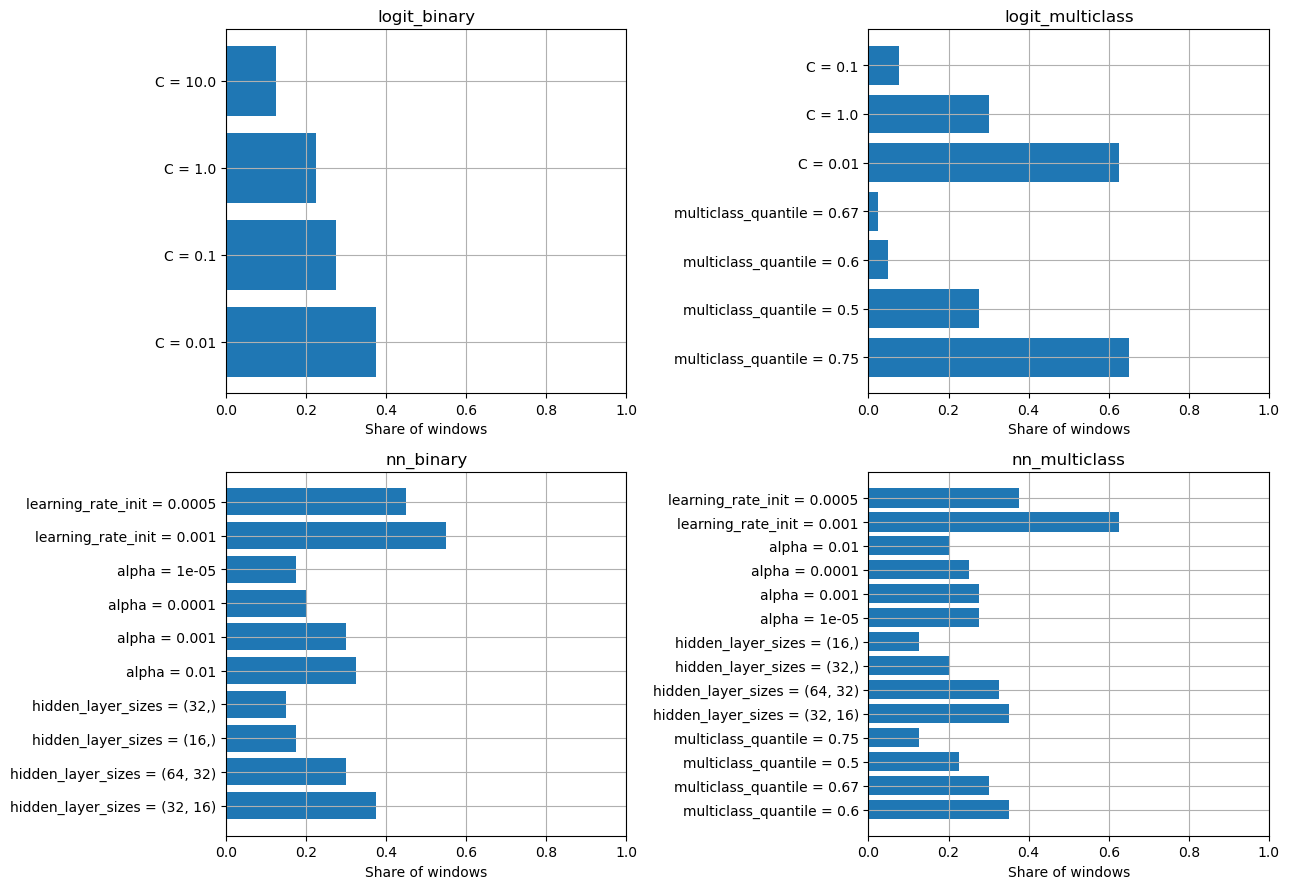

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

model_list = ["logit_binary", "logit_multiclass", "nn_binary", "nn_multiclass"]

for ax, mid in zip(axes, model_list):
    freq = parameter_frequency(best_params_summary, mid).copy()
    if freq.empty:
        ax.set_title(mid)
        ax.axis("off")
        continue

    freq["label"] = freq["parameter"] + " = " + freq["choice"]
    ax.barh(freq["label"], freq["share_within_parameter"])
    ax.set_title(mid)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Share of windows")

plt.tight_layout()
plt.show()


### Speech interpretation of the tuning results

Here is the concise presentation takeaway.

For **binary logit**, the selected penalty is usually on the stronger-shrinkage side: $C=0.01$ appears in **37.5%** of windows, $C=0.1$ in **27.5%**, and $C=1$ in **22.5%**. That says a simple linear model works better when coefficients are kept under control.

For **multiclass logit**, the validation set becomes even more conservative. It selects $C=0.01$ in **62.5%** of windows, and it chooses the high neutral-zone threshold $q=0.75$ in **65%** of windows. That means the validation set often says: *only trade very large expected spread moves; otherwise stay out*.

For **binary NN**, the validation set mostly prefers medium-sized architectures: $(32,16)$ in **37.5%** of windows and $(64,32)$ in **30%**. It also prefers nontrivial penalties, with $\alpha=0.01$ in **32.5%** and $\alpha=0.001$ in **30%**. So even the nonlinear model needs shrinkage.

For **multiclass NN**, the selected quantiles are more balanced: $0.60$ and $0.67$ together account for **65%** of windows, and the preferred hidden layers are again mostly $(32,16)$ and $(64,32)$. So the validation set does not ask for an extremely aggressive neutral class, but it still asks for moderate regularization and moderate network size.

My interpretation is that the validation set sees a **noisy prediction problem**. It rewards shrinkage, and especially in the multiclass logit case it rewards being selective about when to trade.


## 8. Model-fit evaluation

Now I separate **prediction accuracy** from **portfolio value**.

This is crucial.  
A model can be statistically accurate but economically weak, especially if it earns its accuracy by predicting the neutral class too often.

So I first ask: *Which model generalizes best as a classifier?*  
Then I ask: *Which model turns that prediction into tradable returns?*


In [6]:
class_mean = (
    classification_summary
    .groupby(["model_id", "split"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        n_windows=("window_id", "nunique"),
        mean_n_obs=("n_obs", "mean"),
    )
    .sort_values(["split", "mean_accuracy"], ascending=[True, False])
)

class_pivot = class_mean.pivot(index="model_id", columns="split", values="mean_accuracy")
display(class_mean)
display(class_pivot.sort_index())


,model_id,split,mean_accuracy,std_accuracy,n_windows,mean_n_obs
3,logit_multiclass,test,0.650707,0.180265,40,62.90
6,nn_binary,test,0.493911,0.070231,40,62.90
0,logit_binary,test,0.488136,0.064225,40,62.90
9,nn_multiclass,test,0.457205,0.156759,40,62.90
7,nn_binary,train,0.774726,0.104203,40,1258.25
10,nn_multiclass,train,0.772082,0.098684,40,1258.25
4,logit_multiclass,train,0.673162,0.110402,40,1258.25
1,logit_binary,train,0.541984,0.008364,40,1258.25
8,nn_binary,val,0.793875,0.111070,40,62.90
11,nn_multiclass,val,0.782362,0.117149,40,62.90


split,test,train,val
model_id,,,
logit_binary,0.488136,0.541984,0.544829
logit_multiclass,0.650707,0.673162,0.654976
nn_binary,0.493911,0.774726,0.793875
nn_multiclass,0.457205,0.772082,0.782362


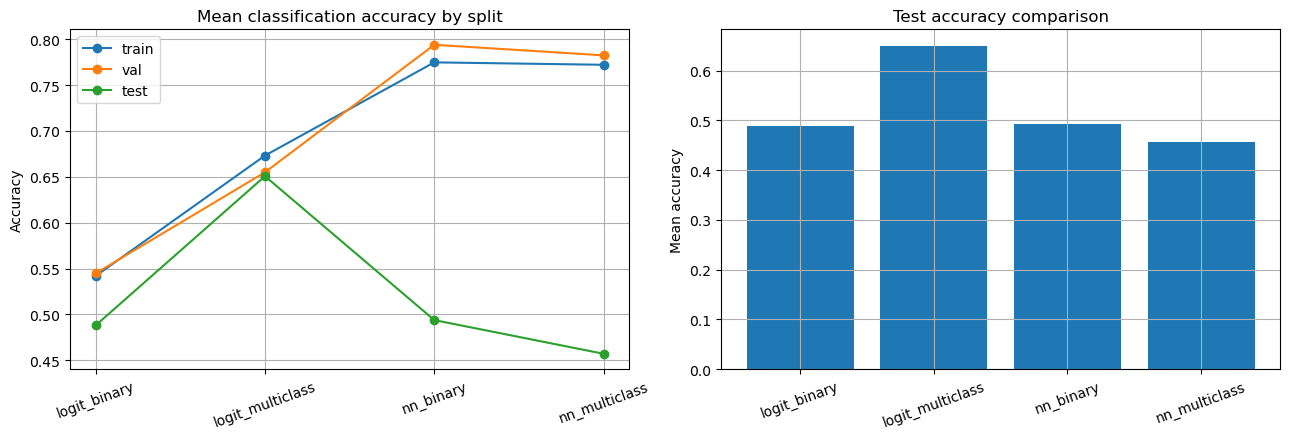

In [7]:
split_order = ["train", "val", "test"]
model_order = ["logit_binary", "logit_multiclass", "nn_binary", "nn_multiclass"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for split in split_order:
    sub = class_mean[class_mean["split"] == split].set_index("model_id").reindex(model_order)
    axes[0].plot(model_order, sub["mean_accuracy"], marker="o", label=split)

axes[0].set_title("Mean classification accuracy by split")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

test_only = class_mean[class_mean["split"] == "test"].set_index("model_id").reindex(model_order)
axes[1].bar(test_only.index, test_only["mean_accuracy"])
axes[1].set_title("Test accuracy comparison")
axes[1].set_ylabel("Mean accuracy")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [8]:
def aggregate_confusion(conf_df, model_id, split):
    sub = conf_df[(conf_df["model_id"] == model_id) & (conf_df["split"] == split)].copy()
    pred_cols = [c for c in sub.columns if c.startswith("pred_")]
    agg = sub.groupby("actual_label")[pred_cols].sum().fillna(0)
    return agg

for mid in ["logit_binary", "logit_multiclass", "nn_binary", "nn_multiclass"]:
    print(f"Aggregated test confusion matrix: {mid}")
    display(aggregate_confusion(confusion_summary, mid, "test"))


Aggregated test confusion matrix: logit_binary


,pred_0,pred_1,pred_-1
actual_label,,,
actual_0,696,535,0.0
actual_1,752,533,0.0


Aggregated test confusion matrix: logit_multiclass


,pred_0,pred_1,pred_-1
actual_label,,,
actual_-1,371,10,40.0
actual_0,1590,11,58.0
actual_1,373,10,53.0


Aggregated test confusion matrix: nn_binary


,pred_0,pred_1,pred_-1
actual_label,,,
actual_0,694,537,0.0
actual_1,736,549,0.0


Aggregated test confusion matrix: nn_multiclass


,pred_0,pred_1,pred_-1
actual_label,,,
actual_-1,304,101,115.0
actual_0,944,232,298.0
actual_1,304,92,126.0


### Speech interpretation of model fit

The cleanest statistical result is that **multiclass logit is the best out-of-sample classifier**.

Its mean accuracies are:

- **train:** 0.6732
- **validation:** 0.6550
- **test:** 0.6507

That is a very stable train-validation-test profile.  
So from a pure classification point of view, the multiclass logit generalizes well.

By contrast, the **NN models look much stronger in train and validation than in test**.

For `nn_binary`, the mean accuracy is:

- **train:** 0.7747
- **validation:** 0.7939
- **test:** 0.4939

For `nn_multiclass`, the mean accuracy is:

- **train:** 0.7721
- **validation:** 0.7824
- **test:** 0.4572

So the neural networks fit the in-sample and validation periods extremely well, but that performance does **not** survive into the final test windows. That is exactly the pattern I would describe as **validation-tuned flexibility failing to generalize**.

The binary logit is much more modest:

- **train:** 0.5420
- **validation:** 0.5448
- **test:** 0.4881

So it is not overfit in the dramatic NN sense, but it also does not have much predictive edge.

The main statistical conclusion is:

1. the NN models look too flexible relative to the signal;
2. the multiclass logit is the most statistically robust model;
3. but statistical robustness is not yet the same thing as trading profitability.


## 9. Portfolio-performance evaluation

Now I move from prediction to the economic question:

**Did the model produce a useful long–short strategy after transaction costs?**

This is the section that matters most for a finance audience.

I compare the models on:

- `strategy_gross`
- `strategy_net`

and benchmark them against:

- a 21-day momentum spread rule,
- always long NVDA and short TSLA,
- a random-walk sign rule.


In [9]:
strategy_summary = (
    portfolio_summary
    .groupby(["model_id", "split", "portfolio_name"], as_index=False)
    .agg(
        mean_cumulative_return=("cumulative_return", "mean"),
        mean_mean_return=("mean_return", "mean"),
        mean_volatility=("volatility", "mean"),
        mean_sharpe=("sharpe", "mean"),
        mean_hit_rate=("hit_rate", "mean"),
        mean_active_rate=("active_rate", "mean"),
        n_windows=("window_id", "nunique"),
    )
)

benchmark_summary = (
    portfolio_summary[
        portfolio_summary["portfolio_name"].isin(
            ["benchmark_mom21", "benchmark_nvda_minus_tsla", "benchmark_random_walk", "benchmark_tsla_minus_nvda"]
        )
    ]
    .groupby(["portfolio_name", "split"], as_index=False)
    .agg(
        mean_cumulative_return=("cumulative_return", "mean"),
        mean_mean_return=("mean_return", "mean"),
        mean_volatility=("volatility", "mean"),
        mean_sharpe=("sharpe", "mean"),
        mean_hit_rate=("hit_rate", "mean"),
        n_windows=("window_id", "nunique"),
    )
)

test_strategy_rank = (
    strategy_summary[
        (strategy_summary["split"] == "test")
        & (strategy_summary["portfolio_name"] == "strategy_net")
    ]
    .sort_values(["mean_sharpe", "mean_cumulative_return"], ascending=False)
    .reset_index(drop=True)
)

display(strategy_summary.sort_values(["split", "portfolio_name", "mean_sharpe"], ascending=[True, True, False]))
display(benchmark_summary.sort_values(["split", "mean_sharpe"], ascending=[True, False]))
display(test_strategy_rank)


,model_id,split,portfolio_name,mean_cumulative_return,mean_mean_return,mean_volatility,mean_sharpe,mean_hit_rate,mean_active_rate,n_windows
0,logit_binary,test,benchmark_mom21,0.048333,0.000718,0.018038,0.040704,0.518288,1.000000,40
18,logit_multiclass,test,benchmark_mom21,0.048333,0.000718,0.018038,0.040704,0.518288,1.000000,40
36,nn_binary,test,benchmark_mom21,0.048333,0.000718,0.018038,0.040704,0.518288,1.000000,40
54,nn_multiclass,test,benchmark_mom21,0.048333,0.000718,0.018038,0.040704,0.518288,1.000000,40
1,logit_binary,test,benchmark_nvda_minus_tsla,0.026407,0.000304,0.017986,0.024860,0.510713,NaN,40
...,...,...,...,...,...,...,...,...,...,...
34,logit_multiclass,val,strategy_gross,0.012066,0.000193,0.001992,0.049085,0.026344,0.047491,40
53,nn_binary,val,strategy_net,0.706245,0.008289,0.015858,0.538654,0.783881,1.000000,40
71,nn_multiclass,val,strategy_net,0.394691,0.005026,0.011728,0.384705,0.238827,0.271041,40
17,logit_binary,val,strategy_net,0.094091,0.001399,0.018055,0.087257,0.540847,1.000000,40


,portfolio_name,split,mean_cumulative_return,mean_mean_return,mean_volatility,mean_sharpe,mean_hit_rate,n_windows
0,benchmark_mom21,test,0.048333,0.000718,0.018038,0.040704,0.518288,40
3,benchmark_nvda_minus_tsla,test,0.026407,0.000304,0.017986,0.024860,0.510713,40
6,benchmark_random_walk,test,-0.009341,-0.000187,0.018045,-0.014006,0.488550,40
9,benchmark_tsla_minus_nvda,test,-0.013111,-0.000304,0.017986,-0.024860,0.488890,40
1,benchmark_mom21,train,1.119560,0.000716,0.017993,0.040182,0.514445,40
4,benchmark_nvda_minus_tsla,train,0.003275,0.000001,0.018003,0.000979,0.505342,40
10,benchmark_tsla_minus_nvda,train,-0.031384,-0.000001,0.018003,-0.000979,0.494460,40
7,benchmark_random_walk,train,-0.539219,-0.000479,0.018001,-0.026510,0.488019,40
2,benchmark_mom21,val,0.055071,0.000818,0.018098,0.046870,0.521066,40
5,benchmark_nvda_minus_tsla,val,0.032478,0.000392,0.018044,0.030163,0.512697,40


,model_id,split,portfolio_name,mean_cumulative_return,mean_mean_return,mean_volatility,mean_sharpe,mean_hit_rate,mean_active_rate,n_windows
0,nn_multiclass,test,strategy_net,-0.014284,-0.000297,0.009422,-0.009480,0.195601,0.383284,40
1,nn_binary,test,strategy_net,-0.036716,-0.000675,0.017997,-0.030136,0.490326,1.000000,40
2,logit_binary,test,strategy_net,-0.042008,-0.000737,0.018029,-0.036977,0.484166,1.000000,40
3,logit_multiclass,test,strategy_net,-0.009512,-0.000159,0.002036,-0.074033,0.032069,0.073911,40


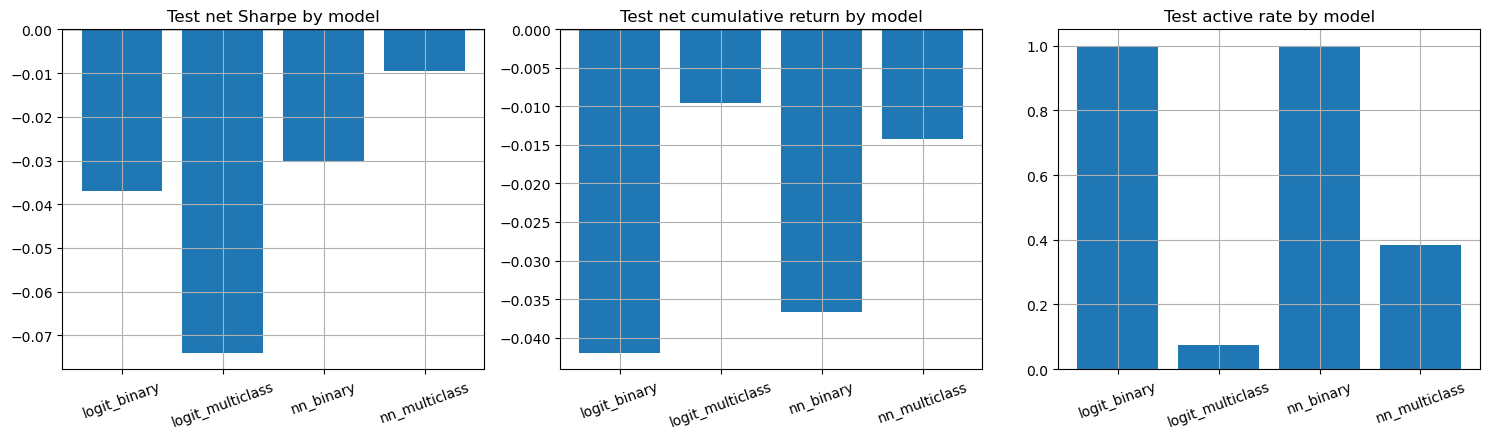

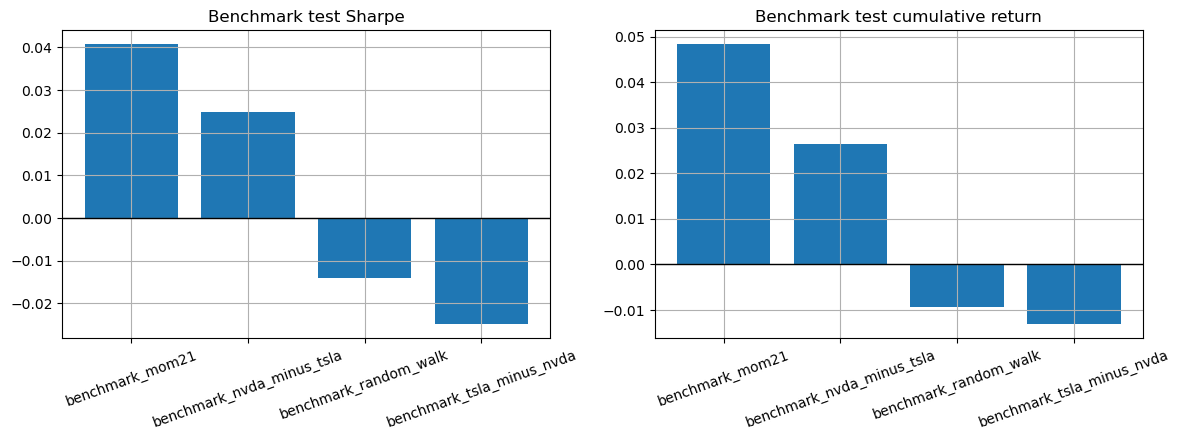

In [10]:
test_net = strategy_summary[
    (strategy_summary["split"] == "test")
    & (strategy_summary["portfolio_name"] == "strategy_net")
].set_index("model_id").reindex(["logit_binary", "logit_multiclass", "nn_binary", "nn_multiclass"])

test_bench = benchmark_summary[benchmark_summary["split"] == "test"].set_index("portfolio_name")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(test_net.index, test_net["mean_sharpe"])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Test net Sharpe by model")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(test_net.index, test_net["mean_cumulative_return"])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Test net cumulative return by model")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(test_net.index, test_net["mean_active_rate"])
axes[2].set_title("Test active rate by model")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bench_order = ["benchmark_mom21", "benchmark_nvda_minus_tsla", "benchmark_random_walk", "benchmark_tsla_minus_nvda"]
axes[0].bar(bench_order, test_bench.loc[bench_order, "mean_sharpe"])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Benchmark test Sharpe")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(bench_order, test_bench.loc[bench_order, "mean_cumulative_return"])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Benchmark test cumulative return")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### Speech interpretation of portfolio performance

This is the most important result of the project.

Across the **test** windows, all four ML strategies have **negative mean net performance**.

For `strategy_net`, the average test results are:

- `nn_multiclass`: cumulative return **-0.0143**, Sharpe **-0.0095**, active rate **0.3833**
- `nn_binary`: cumulative return **-0.0367**, Sharpe **-0.0301**, active rate **1.0000**
- `logit_binary`: cumulative return **-0.0420**, Sharpe **-0.0370**, active rate **1.0000**
- `logit_multiclass`: cumulative return **-0.0095**, Sharpe **-0.0740**, active rate **0.0739**

So none of the ML strategies is economically compelling out of sample.

At the same time, the **benchmarks do better**:

- `benchmark_mom21`: cumulative return **0.0483**, Sharpe **0.0407**
- `benchmark_nvda_minus_tsla`: cumulative return **0.0264**, Sharpe **0.0249**
- `benchmark_random_walk`: cumulative return **-0.0093**, Sharpe **-0.0140**

The immediate conclusion is that the simple 21-day momentum spread rule beats all four ML strategies on the final out-of-sample net test metric.

That is the bottom line a portfolio audience will care about.


## 10. Final comparisons from the three requested angles

This section translates the results directly into the presentation questions.


### Step 1. Does nonlinear structure help?

I compare:

- `logit_binary` versus `nn_binary`
- `logit_multiclass` versus `nn_multiclass`

For the **binary** problem, the NN does slightly better than logit on test net portfolio results:

- `nn_binary` test net Sharpe: **-0.0301**
- `logit_binary` test net Sharpe: **-0.0370**

and

- `nn_binary` test net cumulative return: **-0.0367**
- `logit_binary` test net cumulative return: **-0.0420**

So in the binary case, nonlinear structure helps **a little**, but not enough to turn the strategy positive.

For the **multiclass** problem, the comparison depends on the metric.

- `nn_multiclass` has the better test net Sharpe: **-0.0095** versus **-0.0740**
- `logit_multiclass` has the slightly less negative test cumulative return: **-0.0095** versus **-0.0143**

The reason is economic: `logit_multiclass` trades very little, with active rate only **0.0739**, while `nn_multiclass` is more active at **0.3833**. So the NN is economically more engaged, but it still does not beat the benchmarks.

My presentation takeaway is:

**nonlinear structure does not deliver a decisive out-of-sample advantage.**  
At best it improves the binary model slightly, and in the multiclass case it changes the trade-off between selectivity and activity, but it still fails to beat simple benchmark rules.


### Step 2. Does the neutral class help?

I compare:

- `logit_binary` versus `logit_multiclass`
- `nn_binary` versus `nn_multiclass`

For the **logit** family:

- binary test net Sharpe: **-0.0370**
- multiclass test net Sharpe: **-0.0740**

So for logit, the multiclass version is statistically stronger as a classifier, but economically it becomes too conservative.  
Its test active rate is only **0.0739**, which means it is mostly predicting the neutral class. That raises classification accuracy, but it does not create tradable return.

For the **NN** family:

- binary test net Sharpe: **-0.0301**
- multiclass test net Sharpe: **-0.0095**

and

- binary active rate: **1.0000**
- multiclass active rate: **0.3833**

This is the clearest case where the neutral class helps.  
The NN multiclass model trades less often and loses less on a risk-adjusted basis than the binary NN. So the neutral class is useful as a **trade filter**.

My presentation takeaway is:

**the neutral class helps more in the NN family than in the logit family.**  
It reduces overtrading and improves the NN portfolio results, but it still does not create positive out-of-sample net returns.


### Step 3. Does validation-tuned complexity generalize?

This is where the classification tables are most revealing.

The neural networks look extremely strong in train and validation, but not in test:

- `nn_binary`: 0.7747 train, 0.7939 validation, **0.4939 test**
- `nn_multiclass`: 0.7721 train, 0.7824 validation, **0.4572 test**

So the extra flexibility looks attractive inside the tuning loop, but it does not survive the final holdout period.

By contrast, `logit_multiclass` is very stable:

- 0.6732 train
- 0.6550 validation
- 0.6507 test

So the simpler linear multiclass structure generalizes much better statistically.

My presentation takeaway is:

**validation-tuned complexity in the neural networks does not generalize robustly.**  
The validation set can still be overfit when the candidate class is too flexible, even though it is separated from the training sample.


### Prediction accuracy versus portfolio performance

This is the central economic lesson of the notebook.

The best classifier is `logit_multiclass`, with **0.6507** mean test accuracy.  
But it is **not** the best trading model. Its test active rate is only **0.0739**, and its test net Sharpe is **-0.0740**.

So high classification accuracy here does **not** imply good portfolio performance.

The reason is simple.  
A model can earn high accuracy by correctly predicting many low-action or neutral days. That is useful statistically, but it may not create enough trading opportunities to generate returns after costs.

At the other extreme, the binary models trade every day, with active rate **1.0**, but they lose money because they overtrade noisy signals.

So the project shows a very practical finance point:

$$
\text{prediction accuracy} \neq \text{economic value}.
$$

The right metric for the final decision is **out-of-sample net portfolio performance**, not classification accuracy alone.


### Comparison against benchmarks

When I compare the ML strategies with simple alternatives, the benchmarks win.

On the test sample:

- the 21-day momentum benchmark has Sharpe **0.0407** and cumulative return **0.0483**;
- the always-long-NVDA-short-TSLA benchmark has Sharpe **0.0249** and cumulative return **0.0264**;
- every ML strategy has negative average test net Sharpe.

That means the machine-learning layer does **not** add economic value beyond simple rules in this project.

There is one nuance.  
In the relative-performance table, `nn_multiclass` shows **positive alpha and positive information ratio** versus `benchmark_mom21` and `benchmark_nvda_minus_tsla`:

- versus momentum, net alpha **0.0001**, IR **0.0177**
- versus NVDA-minus-TSLA, net alpha **0.0002**, IR **0.0311**

But I would present that result cautiously, because the raw standalone net return of `nn_multiclass` is still negative.  
So the positive alpha is interesting, but it is not enough to overturn the broader conclusion that the strategy is not economically competitive as a standalone trading rule.


## 11. Wealth-curve view from saved predictions

The wealth curves below are reconstructed from `predictions_all_models.csv`, so again there is no model rerun.

I show:

1. the stitched **test** wealth curves across calendar time;
2. average within-window wealth curves for train, validation, and test.

These figures help separate real out-of-sample persistence from in-sample overfitting.


In [11]:
def stitch_test_wealth(pred_df, return_col="strategy_net"):
    out = []
    test_df = pred_df[pred_df["split"] == "test"].copy()

    for model_id, sub in test_df.groupby("model_id"):
        sub = sub.sort_values("date").copy()
        sub["wealth"] = (1.0 + sub[return_col]).cumprod()
        out.append(sub[["date", "model_id", "wealth"]])

    return pd.concat(out, ignore_index=True)

def average_event_time_wealth(pred_df, split, return_col="strategy_net"):
    rows = []
    sub = pred_df[pred_df["split"] == split].copy()

    for (model_id, window_id), g in sub.groupby(["model_id", "window_id"]):
        g = g.sort_values("date").copy()
        g["event_time"] = np.arange(len(g))
        g["wealth"] = (1.0 + g[return_col]).cumprod()
        rows.append(g[["model_id", "window_id", "event_time", "wealth"]])

    out = pd.concat(rows, ignore_index=True)
    avg = (
        out.groupby(["model_id", "event_time"], as_index=False)
        .agg(mean_wealth=("wealth", "mean"))
    )
    return avg

stitched_test = stitch_test_wealth(predictions, return_col="strategy_net")
train_event = average_event_time_wealth(predictions, "train", return_col="strategy_net")
val_event = average_event_time_wealth(predictions, "val", return_col="strategy_net")
test_event = average_event_time_wealth(predictions, "test", return_col="strategy_net")


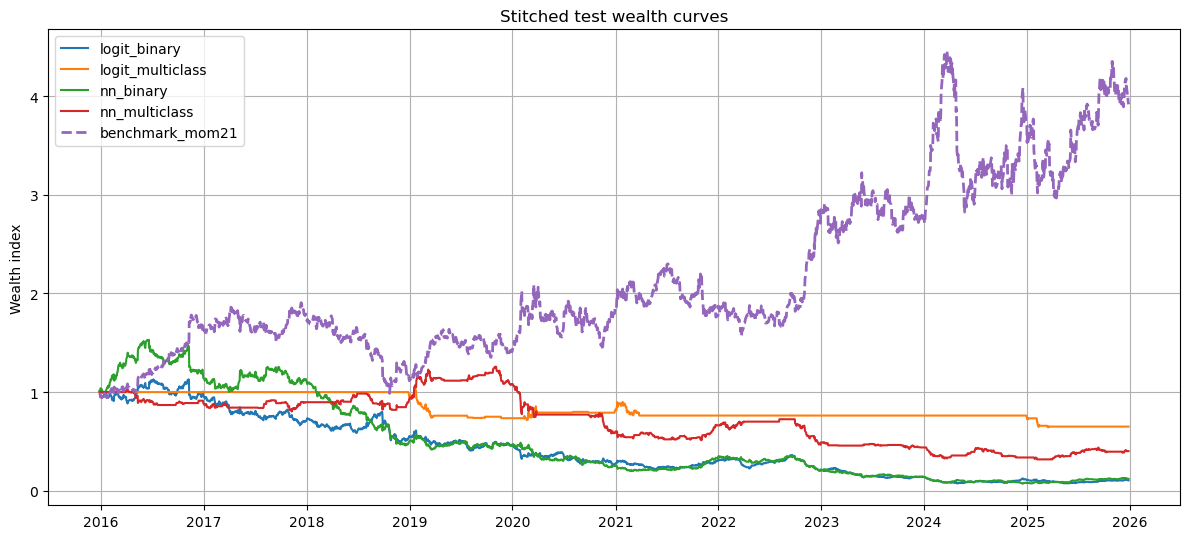

In [12]:
fig, ax = plt.subplots(figsize=(12, 5.5))

for model_id, sub in stitched_test.groupby("model_id"):
    ax.plot(sub["date"], sub["wealth"], label=model_id)

if "benchmark_random_walk" in predictions.columns:
    bench = (
        predictions[predictions["split"] == "test"][["date", "benchmark_mom21"]]
        .drop_duplicates()
        .sort_values("date")
        .copy()
    )
    bench["wealth"] = (1.0 + bench["benchmark_mom21"]).cumprod()
    ax.plot(bench["date"], bench["wealth"], linestyle="--", linewidth=2, label="benchmark_mom21")

ax.set_title("Stitched test wealth curves")
ax.set_ylabel("Wealth index")
ax.legend()
plt.tight_layout()
plt.show()


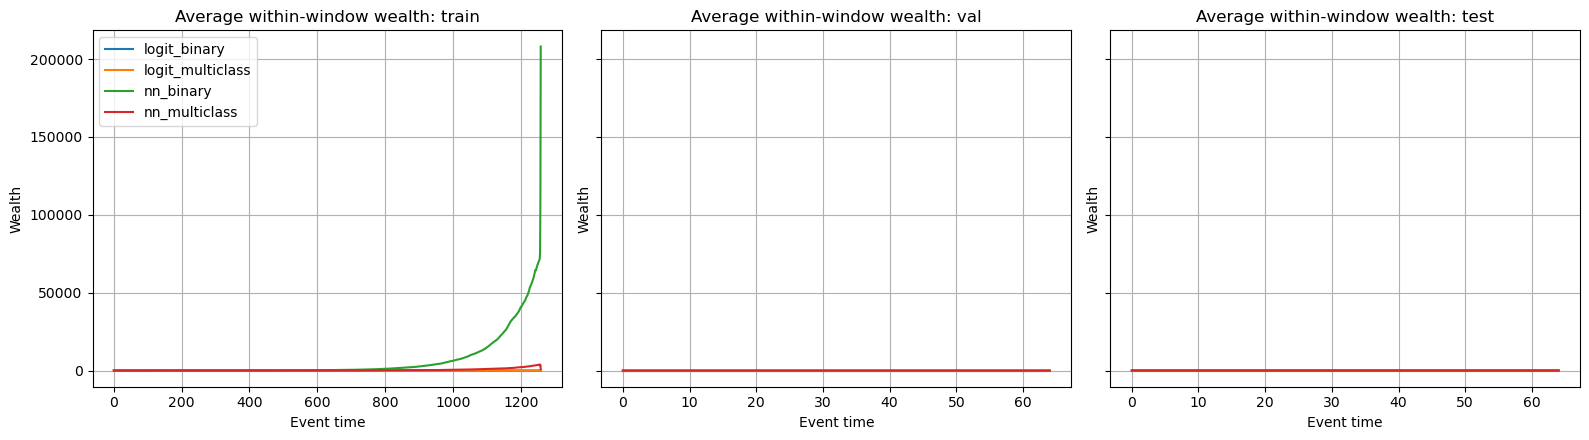

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, avg_df, split in zip(axes, [train_event, val_event, test_event], ["train", "val", "test"]):
    for model_id, sub in avg_df.groupby("model_id"):
        ax.plot(sub["event_time"], sub["mean_wealth"], label=model_id)
    ax.set_title(f"Average within-window wealth: {split}")
    ax.set_xlabel("Event time")
    ax.set_ylabel("Wealth")

axes[0].legend()
plt.tight_layout()
plt.show()


### Speech interpretation of the wealth curves

The wealth curves should be read together with the tables.

If the train curve rises strongly but the validation and test curves flatten or fall, that is overfitting.  
That is exactly the pattern I would expect from the NN models here, given their large drop from validation accuracy to test accuracy.

If a model has flat or slightly negative test wealth but very low activity, then it is statistically selective but economically inactive.  
That is the `logit_multiclass` story.

The most balanced ML strategy is `nn_multiclass`: it trades less than the binary models and holds up better than they do out of sample. But the key point remains that even its net test performance is still below the simple momentum benchmark.


## 12. Final executive summary for the 10-minute presentation

Here is the talk-track version I would use almost word for word.

**Research goal.**  
I asked whether daily accounting and momentum information can predict the next-day NVDA–TSLA return spread well enough to support a profitable long–short strategy.

**Data and design.**  
I started from a daily Mag7 panel, restricted the sample to NVDA and TSLA, built 15 pairwise-difference features, and evaluated four classifiers inside a rolling-window design with 5 years of training data, 3 months of validation, and 3 months of test data. The validation set selected the multiclass threshold and all model hyperparameters using validation Sharpe.

**Statistical result.**  
The strongest out-of-sample classifier is the validation-tuned multiclass logistic regression, with mean test accuracy **0.6507**. It is also the most stable model from train to validation to test.

**Model-complexity result.**  
The neural networks fit the train and validation windows extremely well, but that strength does not generalize to test windows. So the extra nonlinear flexibility is not robust in this setting.

**Economic result.**  
None of the four ML strategies produces positive average out-of-sample net performance. The best standalone ML portfolio is still negative, while the simple 21-day momentum benchmark delivers positive test Sharpe and positive cumulative return.

**Interpretation.**  
So my main conclusion is not that machine learning is useless. The conclusion is narrower and more practical: for this particular NVDA–TSLA spread problem, the available signal is noisy enough that simple regularized structures generalize better statistically, but the economic edge is still too weak to beat simple benchmark rules after trading costs.

**Final takeaway.**  
Prediction accuracy and portfolio value are not the same thing. In this project, the most accurate model is not the most profitable strategy, and the most flexible model is not the most robust one.


In [14]:
# Optional: export compact presentation tables if needed
presentation_tables = {
    "config_snapshot": config_snapshot,
    "class_mean": class_mean,
    "test_strategy_rank": test_strategy_rank,
    "benchmark_summary_test": benchmark_summary[benchmark_summary["split"] == "test"],
    "best_selection_table": best_selection_table,
}

for name, df in presentation_tables.items():
    print(f"\n{name}")
    display(df.head(20))



config_snapshot


,value
symbol_a,NVDA
symbol_b,TSLA
n_features,15
train_years,5
val_months,3
test_months,3
step_months,3
binary_threshold,0.5
transaction_cost_bps,5.0
selection_objective,sharpe



class_mean


,model_id,split,mean_accuracy,std_accuracy,n_windows,mean_n_obs
3,logit_multiclass,test,0.650707,0.180265,40,62.90
6,nn_binary,test,0.493911,0.070231,40,62.90
0,logit_binary,test,0.488136,0.064225,40,62.90
9,nn_multiclass,test,0.457205,0.156759,40,62.90
7,nn_binary,train,0.774726,0.104203,40,1258.25
10,nn_multiclass,train,0.772082,0.098684,40,1258.25
4,logit_multiclass,train,0.673162,0.110402,40,1258.25
1,logit_binary,train,0.541984,0.008364,40,1258.25
8,nn_binary,val,0.793875,0.111070,40,62.90
11,nn_multiclass,val,0.782362,0.117149,40,62.90



test_strategy_rank


,model_id,split,portfolio_name,mean_cumulative_return,mean_mean_return,mean_volatility,mean_sharpe,mean_hit_rate,mean_active_rate,n_windows
0,nn_multiclass,test,strategy_net,-0.014284,-0.000297,0.009422,-0.009480,0.195601,0.383284,40
1,nn_binary,test,strategy_net,-0.036716,-0.000675,0.017997,-0.030136,0.490326,1.000000,40
2,logit_binary,test,strategy_net,-0.042008,-0.000737,0.018029,-0.036977,0.484166,1.000000,40
3,logit_multiclass,test,strategy_net,-0.009512,-0.000159,0.002036,-0.074033,0.032069,0.073911,40



benchmark_summary_test


,portfolio_name,split,mean_cumulative_return,mean_mean_return,mean_volatility,mean_sharpe,mean_hit_rate,n_windows
0,benchmark_mom21,test,0.048333,0.000718,0.018038,0.040704,0.518288,40
3,benchmark_nvda_minus_tsla,test,0.026407,0.000304,0.017986,0.024860,0.510713,40
6,benchmark_random_walk,test,-0.009341,-0.000187,0.018045,-0.014006,0.488550,40
9,benchmark_tsla_minus_nvda,test,-0.013111,-0.000304,0.017986,-0.024860,0.488890,40



best_selection_table


,model_id,window_id,selection_metric,val_accuracy,val_cumulative_return,val_sharpe,multiclass_quantile,C,hidden_layer_sizes,alpha,learning_rate_init
0,logit_binary,win_01,-0.086344,0.428571,-0.096512,-0.086344,NaN,10.00,NaN,NaN,NaN
1,logit_binary,win_02,0.063125,0.524590,0.055667,0.063125,NaN,1.00,NaN,NaN,NaN
2,logit_binary,win_03,-0.094633,0.538462,-0.099373,-0.094633,NaN,0.10,NaN,NaN,NaN
3,logit_binary,win_04,0.117973,0.625000,0.076761,0.117973,NaN,0.01,NaN,NaN,NaN
4,logit_binary,win_05,-0.003047,0.587302,-0.019149,-0.003047,NaN,0.01,NaN,NaN,NaN
5,logit_binary,win_06,-0.146473,0.459016,-0.118925,-0.146473,NaN,0.01,NaN,NaN,NaN
6,logit_binary,win_07,-0.034326,0.515625,-0.048673,-0.034326,NaN,0.10,NaN,NaN,NaN
7,logit_binary,win_08,0.145902,0.578125,0.130776,0.145902,NaN,0.01,NaN,NaN,NaN
8,logit_binary,win_09,-0.012184,0.507937,-0.014970,-0.012184,NaN,1.00,NaN,NaN,NaN
9,logit_binary,win_10,0.045445,0.475410,0.032895,0.045445,NaN,0.01,NaN,NaN,NaN
